# Day 4: Tune & Ensemble a Classifier

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## 1. Data Loading

In [6]:
url = "https://raw.githubusercontent.com/Vvijayaragupathy-uno/machinelearning/main/day%204/WA_Fn-UseC_-Telco-Customer-Churn.csv"
data = pd.read_csv(url)

print(data.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

## 2. Understanding the Data

In [7]:
# Check how many rows and columns
print("Data Shape:")
print(data.shape)

# Check data types
print("\nData Info:")
print(data.info())

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

Data Shape:
(7043, 21)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperle

## 3. Exploratory Data Analysis (EDA) - Target Variable

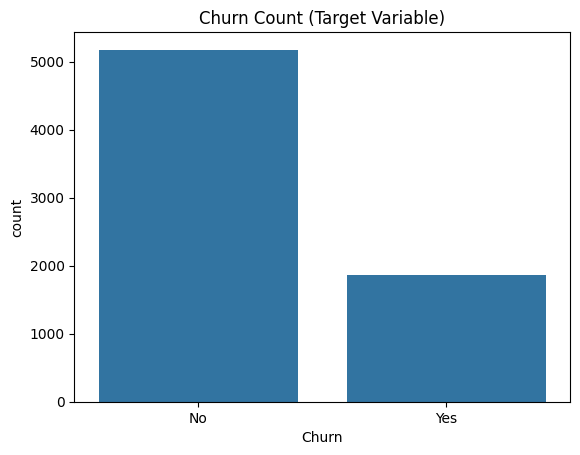

In [8]:
# Plot the target variable to see if our data is balanced
sns.countplot(data=data, x='Churn')
plt.title("Churn Count (Target Variable)")
plt.show()

## 4. Exploratory Data Analysis (EDA) - Numerical Features

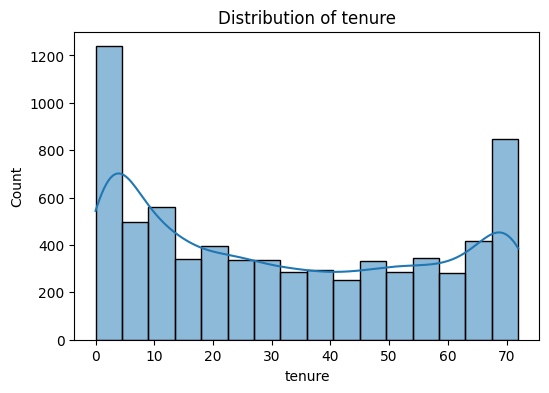

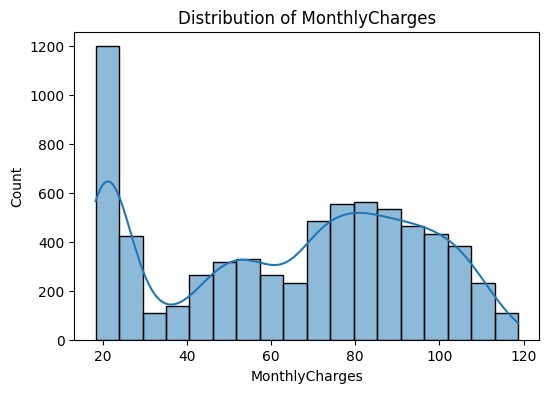

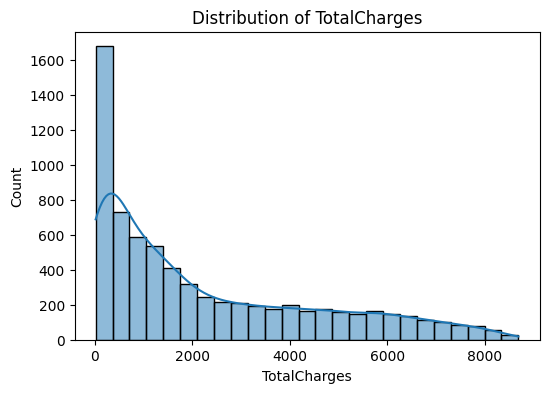

In [9]:
# First, fix TotalCharges so we can plot it (it is currently an object/text)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Plot histograms for our numerical columns
numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## 5. Exploratory Data Analysis (EDA) - Categorical Features

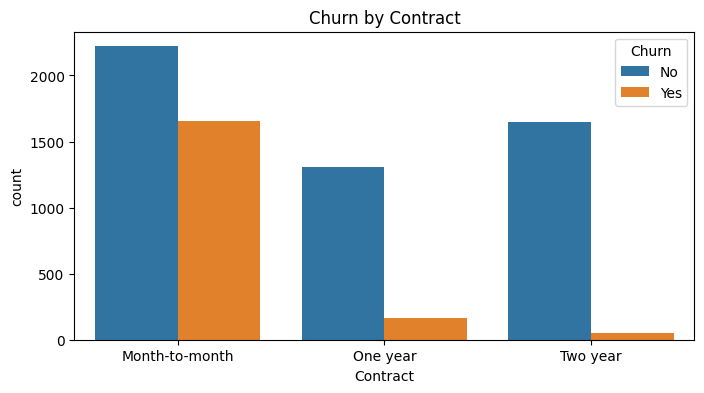

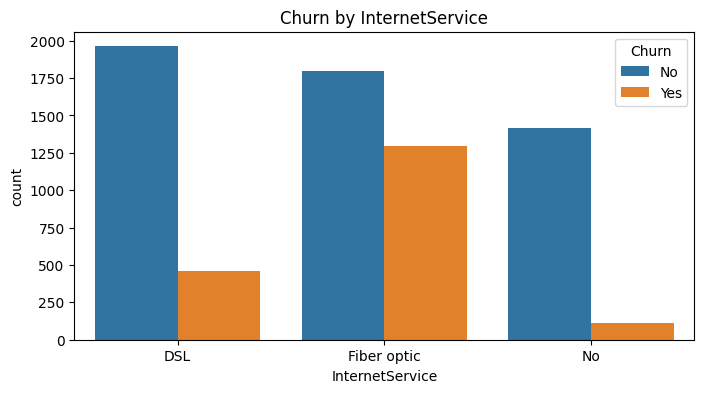

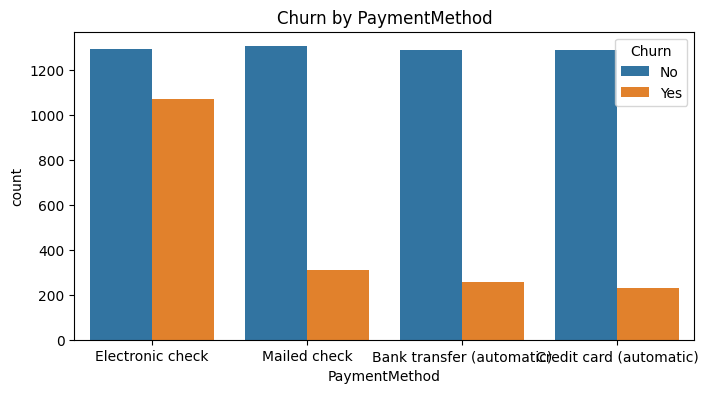

In [10]:
# Let's see how different categories relate to Churn
# We'll pick a few important ones: Contract, InternetService, and PaymentMethod

categorical_columns_to_plot = ['Contract', 'InternetService', 'PaymentMethod']

for col in categorical_columns_to_plot:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=data, x=col, hue='Churn')
    plt.title(f"Churn by {col}")
    plt.show()

## 6. Data Cleaning & Preprocessing

In [11]:
# 1. Drop customerID because it's just a random ID (no predictive power)
data = data.drop(columns=['customerID'])

# 2. Fill missing TotalCharges with the median value (since we already converted to numeric in step 4)
median_charge = data['TotalCharges'].median()
data['TotalCharges'] = data['TotalCharges'].fillna(median_charge)

# 3. Change Churn 'Yes' and 'No' to 1 and 0
data['Churn'] = data['Churn'].replace({'Yes': 1, 'No': 0})

# 4. Separate features (X) and target (y)
X = data.drop(columns=['Churn'])
y = data['Churn']

# 5. Convert all remaining text columns to numbers (One-Hot Encoding)
X = pd.get_dummies(X)

# 6. Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Scale the features (make them all have similar range, important for many models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

/tmp/ipykernel_648/238011820.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Churn'] = data['Churn'].replace({'Yes': 1, 'No': 0})


## 7. Baseline Model (Decision Tree)

In [12]:
# Create the Decision Tree model
baseline_tree = DecisionTreeClassifier(random_state=42)

# 5-Fold Cross Validation
cv_scores = cross_val_score(baseline_tree, X_train, y_train, cv=5)
baseline_cv_accuracy = cv_scores.mean()

# Train the model and test it
baseline_tree.fit(X_train, y_train)
predictions = baseline_tree.predict(X_test)
baseline_test_accuracy = accuracy_score(y_test, predictions)

print("Baseline CV Accuracy:", round(baseline_cv_accuracy, 4))
print("Baseline Test Accuracy:", round(baseline_test_accuracy, 4))

Baseline CV Accuracy: 0.7306
Baseline Test Accuracy: 0.7154


## 8. Hyperparameter Tuning with GridSearchCV

In [13]:
# Create a dictionary of parameters to try
grid_parameters = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Create Grid Search
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), grid_parameters, cv=5)

# Train Grid Search (this tries all combinations)
grid_search.fit(X_train, y_train)

# Get best results
best_grid_model = grid_search.best_estimator_
grid_best_params = grid_search.best_params_
grid_cv_accuracy = grid_search.best_score_

# Test the best model
grid_predictions = best_grid_model.predict(X_test)
grid_test_accuracy = accuracy_score(y_test, grid_predictions)

print("Grid Search Best Parameters:", grid_best_params)
print("Grid Search CV Accuracy:", round(grid_cv_accuracy, 4))
print("Grid Search Test Accuracy:", round(grid_test_accuracy, 4))

Grid Search Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
Grid Search CV Accuracy: 0.7867
Grid Search Test Accuracy: 0.7999


## 9. Hyperparameter Tuning with RandomizedSearchCV

In [14]:
# Create a dictionary of parameters to try randomly
random_parameters = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Create Random Search (try 20 random combinations)
random_search = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), random_parameters, n_iter=20, cv=5, random_state=42)

# Train Random Search
random_search.fit(X_train, y_train)

# Get best results
best_random_model = random_search.best_estimator_
random_best_params = random_search.best_params_
random_cv_accuracy = random_search.best_score_

# Test the best model
random_predictions = best_random_model.predict(X_test)
random_test_accuracy = accuracy_score(y_test, random_predictions)

print("Random Search Best Parameters:", random_best_params)
print("Random Search CV Accuracy:", round(random_cv_accuracy, 4))
print("Random Search Test Accuracy:", round(random_test_accuracy, 4))

Random Search Best Parameters: {'min_samples_split': 20, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'gini'}
Random Search CV Accuracy: 0.7867
Random Search Test Accuracy: 0.7999


## 10. Ensemble Model (Random Forest)

In [15]:
# Create the Random Forest model (100 trees)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 5-Fold Cross Validation
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)
rf_cv_accuracy = rf_cv_scores.mean()

# Train the model and test it
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_test_accuracy = accuracy_score(y_test, rf_predictions)

# Parameters used
rf_best_params = {'n_estimators': 100, 'random_state': 42}

print("Random Forest CV Accuracy:", round(rf_cv_accuracy, 4))
print("Random Forest Test Accuracy:", round(rf_test_accuracy, 4))

Random Forest CV Accuracy: 0.7845
Random Forest Test Accuracy: 0.797


## 11. Summary Table

In [16]:
# Create lists of our results
models = ['Decision Tree (Baseline)', 'Decision Tree (GridSearch)', 'Decision Tree (RandomSearch)', 'Random Forest (Ensemble)']
cv_scores = [baseline_cv_accuracy, grid_cv_accuracy, random_cv_accuracy, rf_cv_accuracy]
test_scores = [baseline_test_accuracy, grid_test_accuracy, random_test_accuracy, rf_test_accuracy]
parameters = ['Default', str(grid_best_params), str(random_best_params), str(rf_best_params)]

# Put the lists into a pandas DataFrame (a table)
summary_table = pd.DataFrame({
    'Model': models,
    'CV Accuracy': cv_scores,
    'Test Accuracy': test_scores,
    'Best Params': parameters
})

# Show the final table
display(summary_table)

,Model,CV Accuracy,Test Accuracy,Best Params
0,Decision Tree (Baseline),0.730565,0.715401,Default
1,Decision Tree (GridSearch),0.786653,0.799858,"{'criterion': 'gini', 'max_depth': 5, 'min_sam..."
2,Decision Tree (RandomSearch),0.786653,0.799858,"{'min_samples_split': 20, 'min_samples_leaf': ..."
3,Random Forest (Ensemble),0.784522,0.797019,"{'n_estimators': 100, 'random_state': 42}"
